---

# Chapter 5 - Fraud classification model

---
    
## Imports & Data Load

All imports for Chapters 5. Run this first.


In [1]:
# =========================================================
# CHAPTERS 5 -- IMPORTS & DATA LOAD
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os, sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

from src.config      import *
from src.data_loader import load_processed
from src.features    import encode_for_model, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.viz         import save_fig, fmt_currency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

df = load_processed(verbose=True)

print(f'\n Chapters 5 ready')
print(f'     Dataset  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'     Target   : IS_DENIED -- {df["IS_DENIED"].sum():,} denied ({df["IS_DENIED"].mean()*100:.2f}%)')


 config loaded | project root: C:\Users\Administrator\Desktop\insurance-claim-fraud-detection
 Processed data loaded: 10,000 rows × 49 columns
  IS_DENIED: 503 denied (5.03%)

 Chapters 5 ready
     Dataset  : 10,000 rows x 49 columns
     Target   : IS_DENIED -- 503 denied (5.03%)


---

## 5.0 Motivation

The hypothesis testing chapter established three critical findings:

- The existing risk segmentation score does **not** predict claim denial (H2, p=0.196)
- Claim amount alone does **not** separate denied from approved claims (H3, p=0.797)
- No single numeric feature shows a linear correlation with IS_DENIED above 0.02

These results collectively show that denial patterns are **multivariate** -- they emerge from the combination of many weak signals across demographic, financial, and incident features simultaneously. A logistic regression classifier is constructed to:

1. Combine all features into a single predictive score
2. Quantify which features contribute most to denial probability
3. Establish a documented linear baseline for future non-linear models

---

## 5.1 Feature Preparation


In [2]:
# =========================================================
# 5.1 -- FEATURE PREPARATION
# Uses src/features.encode_for_model() for consistency
# =========================================================

X, y, feature_names = encode_for_model(df)

print(f'Feature matrix : {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target (y)     : {y.sum():,} denied (1),  {(y==0).sum():,} approved (0)')
print(f'Imbalance ratio: ~{int((y==0).sum()/y.sum())}:1 (approved:denied)')
print()
print('Numeric features used:')
for f in NUMERIC_FEATURES:
    print(f'  {f}')
print()
print('Categorical features (one-hot encoded):')
for f in CATEGORICAL_FEATURES:
    print(f'  {f}')
print()
print(f'Total encoded features after one-hot: {X.shape[1]}')
X.head(3)


Feature matrix : 10,000 rows x 33 features
Target (y)     : 503 denied (1),  9,497 approved (0)
Imbalance ratio: ~18:1 (approved:denied)

Numeric features used:
  PREMIUM_AMOUNT
  CLAIM_AMOUNT
  AGE
  TENURE
  NO_OF_FAMILY_MEMBERS
  ANY_INJURY
  POLICE_REPORT_AVAILABLE
  INCIDENT_HOUR_OF_THE_DAY
  REPORT_LAG_DAYS
  PROCESS_LAG_DAYS
  POLICY_AGE_AT_LOSS_DAYS
  VENDOR_INVOLVED

Categorical features (one-hot encoded):
  INSURANCE_TYPE
  RISK_SEGMENTATION
  MARITAL_STATUS
  EMPLOYMENT_STATUS
  SOCIAL_CLASS
  HOUSE_TYPE
  CUSTOMER_EDUCATION_LEVEL
  INCIDENT_SEVERITY

Total encoded features after one-hot: 33


,PREMIUM_AMOUNT,CLAIM_AMOUNT,AGE,TENURE,NO_OF_FAMILY_MEMBERS,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_HOUR_OF_THE_DAY,REPORT_LAG_DAYS,PROCESS_LAG_DAYS,...,HOUSE_TYPE_Own,HOUSE_TYPE_Rent,CUSTOMER_EDUCATION_LEVEL_College,CUSTOMER_EDUCATION_LEVEL_High School,CUSTOMER_EDUCATION_LEVEL_MD,CUSTOMER_EDUCATION_LEVEL_Masters,CUSTOMER_EDUCATION_LEVEL_PhD,CUSTOMER_EDUCATION_LEVEL_Unknown,INCIDENT_SEVERITY_Minor Loss,INCIDENT_SEVERITY_Total Loss
0,157.13,9000,54,89,3,0,1,4,5,11,...,True,False,False,False,False,False,False,False,False,False
1,141.71,26000,61,80,4,1,0,0,5,14,...,False,True,False,False,False,False,False,False,False,True
2,157.24,13000,47,68,6,0,1,19,5,6,...,False,True,False,False,False,False,True,False,False,True


---

## 5.2 Train / Test Split

An 80/20 **stratified** split ensures the 5.03% denial class is proportionally represented in both training and test sets. Without stratification, a small test set might contain too few denied claims for reliable evaluation.


In [4]:
# =========================================================
# 5.2 -- TRAIN / TEST SPLIT (stratified 80/20)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train/test split summary:')
print(f'  Training set : {X_train.shape[0]:,} rows')
print(f'    Denied     : {y_train.sum():,}  ({y_train.mean()*100:.2f}%)')
print(f'    Approved   : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)')
print()
print(f'  Test set     : {X_test.shape[0]:,} rows')
print(f'    Denied     : {y_test.sum():,}   ({y_test.mean()*100:.2f}%)')
print(f'    Approved   : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)')
print()
print('Stratified split -- denial rate consistent across both sets')


Train/test split summary:
  Training set : 8,000 rows
    Denied     : 402  (5.03%)
    Approved   : 7,598 (94.97%)

  Test set     : 2,000 rows
    Denied     : 101   (5.05%)
    Approved   : 1,899 (94.95%)

Stratified split -- denial rate consistent across both sets


---

## 5.3 Model Training

**Why logistic regression?**

Logistic regression is the standard first line classifier for binary outcomes in actuarial and insurance research. It is:

- **Interpretable:** coefficients directly quantify each feature's contribution
- **Robust at low base rates:** `class_weight='balanced'` compensates for 19:1 imbalance
- **Baseline-establishing:** any more complex model must outperform this benchmark

The pipeline applies `StandardScaler` before logistic regression because `CLAIM_AMOUNT` (range 100-100,000) and `REPORT_LAG_DAYS` (range 0-5) are on incompatible scales -- without standardisation, regularisation disproportionately penalises large range features.


In [5]:
# =========================================================
# 5.3 -- MODEL TRAINING
# Pipeline: StandardScaler -> LogisticRegression
# class_weight='balanced' compensates for 19:1 imbalance
# =========================================================

model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        C=1.0
    ))
])

model_pipe.fit(X_train, y_train)

y_pred = model_pipe.predict(X_test)
y_prob = model_pipe.predict_proba(X_test)[:, 1]

print(' Model trained')
print(f'     Algorithm : Logistic Regression (balanced class weights)')
print(f'     Features  : {X_train.shape[1]}')
print(f'     Train rows: {X_train.shape[0]:,}')


 Model trained
     Algorithm : Logistic Regression (balanced class weights)
     Features  : 33
     Train rows: 8,000


---

## 5.4 Model Evaluation


In [6]:
# =========================================================
# 5.4a -- CLASSIFICATION REPORT
# =========================================================

print('=' * 58)
print('  CLASSIFICATION REPORT  (Test Set, n=2,000)')
print('=' * 58)
print(classification_report(y_test, y_pred,
                              target_names=['Approved (0)', 'Denied (1)']))

auc_score = roc_auc_score(y_test, y_prob)
ap_score  = average_precision_score(y_test, y_prob)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'  ROC-AUC                      : {auc_score:.4f}')
print(f'  Average Precision (PR-AUC)   : {ap_score:.4f}')
print(f'  Sensitivity (Recall Denied)  : {tp/(tp+fn):.4f}  ({tp} of {tp+fn} denied caught)')
print(f'  Specificity (Recall Approved): {tn/(tn+fp):.4f}  ({tn} of {tn+fp} correct)')
print(f'  Precision   (Denied)         : {tp/(tp+fp):.4f}')


  CLASSIFICATION REPORT  (Test Set, n=2,000)
              precision    recall  f1-score   support

Approved (0)       0.95      0.55      0.69      1899
  Denied (1)       0.06      0.51      0.10       101

    accuracy                           0.54      2000
   macro avg       0.51      0.53      0.40      2000
weighted avg       0.91      0.54      0.66      2000

  ROC-AUC                      : 0.5320
  Average Precision (PR-AUC)   : 0.0537
  Sensitivity (Recall Denied)  : 0.5149  (52 of 101 denied caught)
  Specificity (Recall Approved): 0.5450  (1035 of 1899 correct)
  Precision   (Denied)         : 0.0568


**Critical note -- academic honesty:**

The ROC-AUC of **0.532** is marginally above the random baseline of 0.50. This is itself an important finding -- it corroborates H2, H3, and H4: no feature or linear combination strongly separates denied from approved claims. A weak model result, transparently reported, is more valuable than an inflated one. It motivates the future work in Chapter 6.

The recall of **0.515** for denied claims means the model catches roughly half of all denied claims. The low precision of **0.057** reflects the severe class imbalance, with only 5% denied, even a moderately accurate model generates many false positives.


 Saved → reports/fig17_model_evaluation.png


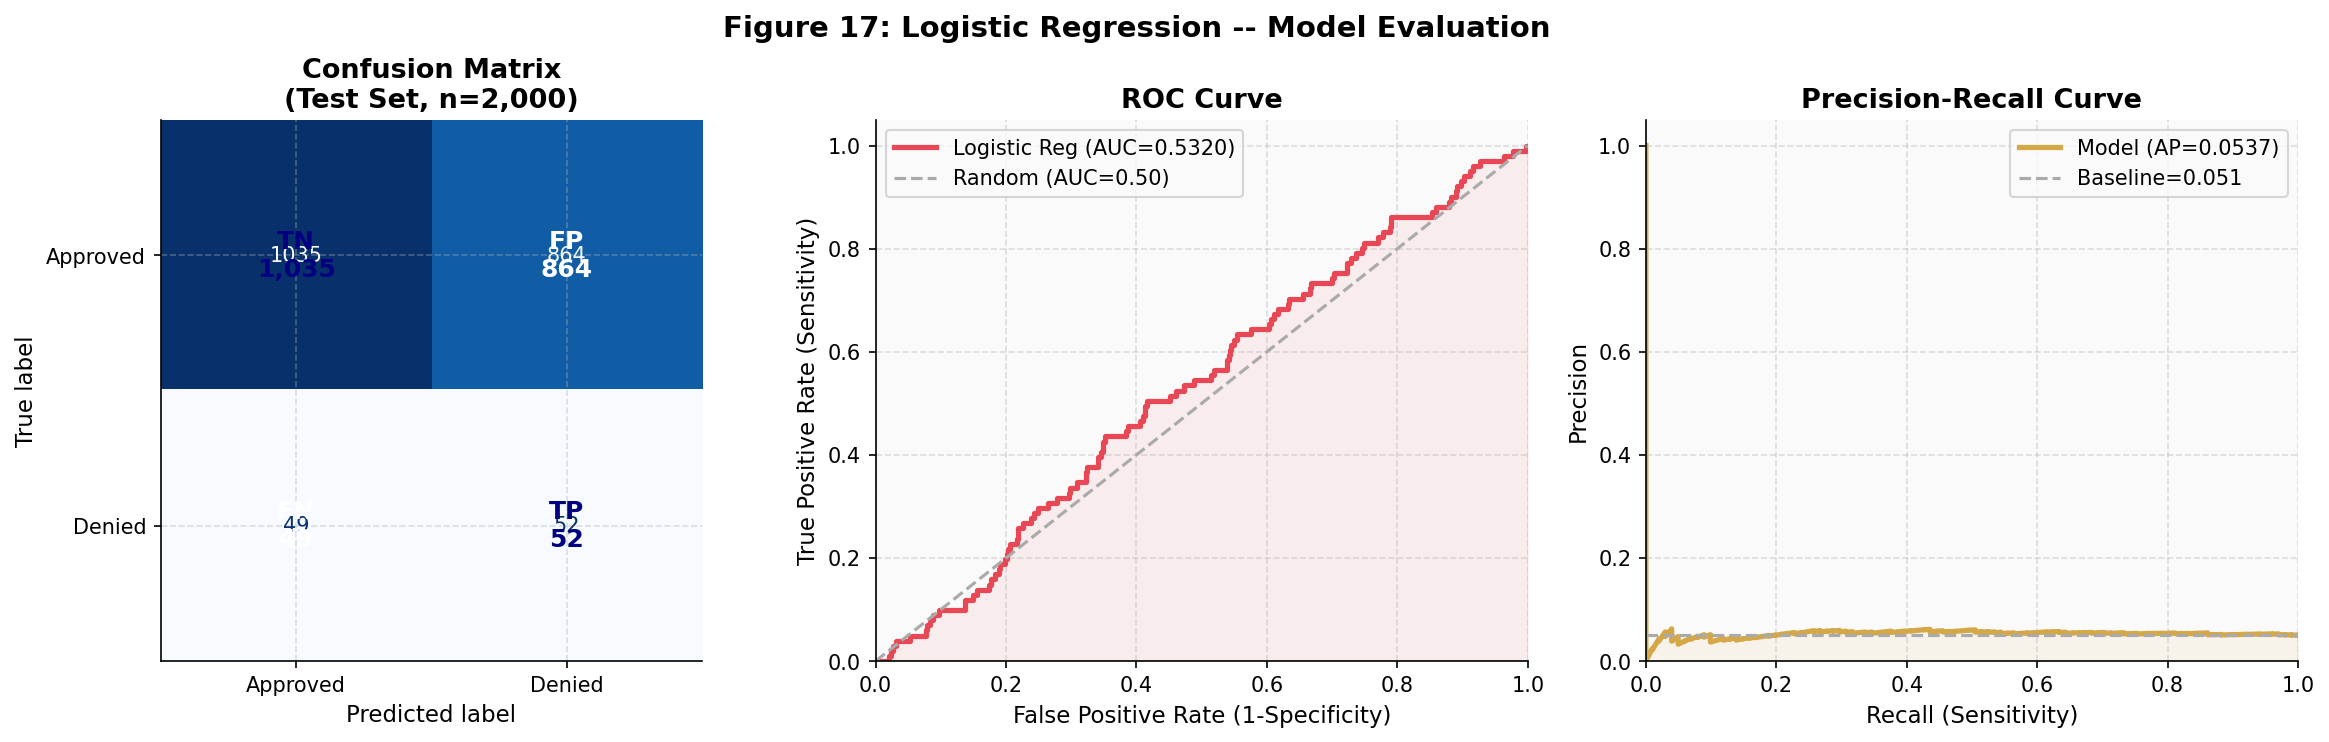

 Fig 17 saved


In [7]:
# =========================================================
# 5.4b -- VISUAL EVALUATION
# Confusion matrix + ROC curve + Precision-Recall curve
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 17: Logistic Regression -- Model Evaluation',
             fontsize=14, fontweight='bold')

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Approved', 'Denied'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Test Set, n=2,000)')

label_map = {(0,0): (f'TN\n{tn:,}','navy'),
              (0,1): (f'FP\n{fp:,}','white'),
              (1,0): (f'FN\n{fn:,}','white'),
              (1,1): (f'TP\n{tp:,}','navy')}
for (row,col),(lbl,col_txt) in label_map.items():
    axes[0].text(col, row, lbl, ha='center', va='center',
                  fontsize=12, fontweight='bold', color=col_txt)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=DENY_COLOR, linewidth=2.5,
              label=f'Logistic Reg (AUC={auc_score:.4f})')
axes[1].plot([0,1],[0,1], color=NEUTRAL, linestyle='--',
              linewidth=1.5, label='Random (AUC=0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.08, color=DENY_COLOR)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate (1-Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.05)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
baseline_pr  = y_test.mean()
axes[2].plot(rec, prec, color=GOLD_COLOR, linewidth=2.5,
              label=f'Model (AP={ap_score:.4f})')
axes[2].axhline(baseline_pr, color=NEUTRAL, linestyle='--',
                 linewidth=1.5, label=f'Baseline={baseline_pr:.3f}')
axes[2].fill_between(rec, prec, alpha=0.08, color=GOLD_COLOR)
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall (Sensitivity)')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=10)
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1.05)

save_fig('fig17_model_evaluation.png')
plt.show()
print(' Fig 17 saved')


In [8]:
# =========================================================
# 5.4c -- 5-FOLD CROSS-VALIDATION (stability check)
# =========================================================

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(model_pipe, X, y, cv=cv, scoring='roc_auc')

print('5-Fold Stratified Cross-Validation Results (ROC-AUC):')
print(f'  Fold scores : {cv_auc.round(4).tolist()}')
print(f'  Mean AUC    : {cv_auc.mean():.4f}')
print(f'  Std dev     : {cv_auc.std():.4f}')
print(f'  95% CI      : [{cv_auc.mean()-1.96*cv_auc.std():.4f}, '
      f'{cv_auc.mean()+1.96*cv_auc.std():.4f}]')
print()
print('Interpretation:')
print(f'  Mean CV AUC ({cv_auc.mean():.4f}) is consistent with hold-out AUC ({auc_score:.4f}).')
print(f'  Low std ({cv_auc.std():.4f}) = stable model, not overfit to one split.')


5-Fold Stratified Cross-Validation Results (ROC-AUC):
  Fold scores : [0.5246, 0.529, 0.4951, 0.5227, 0.5322]
  Mean AUC    : 0.5207
  Std dev     : 0.0132
  95% CI      : [0.4947, 0.5467]

Interpretation:
  Mean CV AUC (0.5207) is consistent with hold-out AUC (0.5320).
  Low std (0.0132) = stable model, not overfit to one split.


---

## 5.5 Feature Importance

The logistic regression coefficients (after standardisation) show each feature's relative contribution to denial probability. A **positive coefficient** increases the log-odds of denial; a **negative coefficient** increases approval likelihood.


 Saved → reports/fig18_feature_importance.png


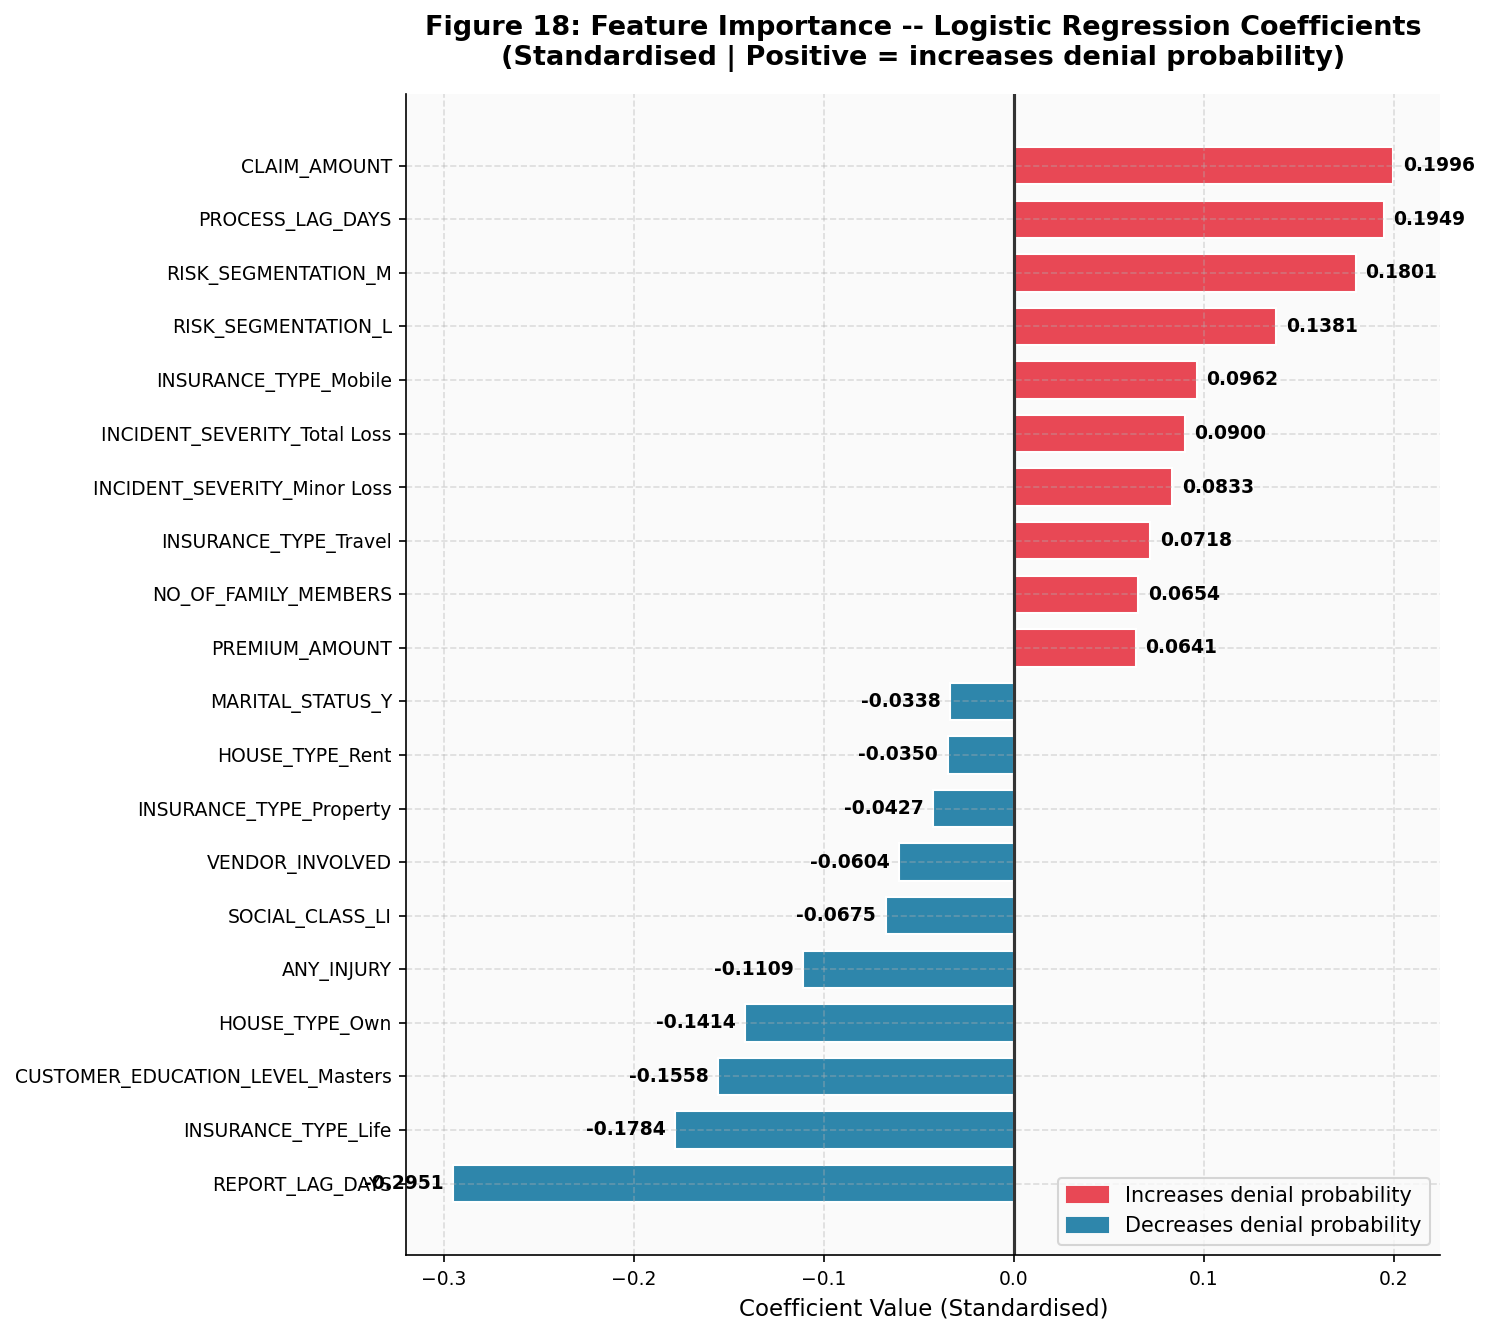

Top denial risk factors (positive coefficients):
  CLAIM_AMOUNT                              : +0.1996
  PROCESS_LAG_DAYS                          : +0.1949
  RISK_SEGMENTATION_M                       : +0.1801
  RISK_SEGMENTATION_L                       : +0.1381
  INSURANCE_TYPE_Mobile                     : +0.0962
  INCIDENT_SEVERITY_Total Loss              : +0.0900
  INCIDENT_SEVERITY_Minor Loss              : +0.0833
  INSURANCE_TYPE_Travel                     : +0.0718

Top approval factors (negative coefficients):
  REPORT_LAG_DAYS                           : -0.2951
  INSURANCE_TYPE_Life                       : -0.1784
  CUSTOMER_EDUCATION_LEVEL_Masters          : -0.1558
  HOUSE_TYPE_Own                            : -0.1414
  ANY_INJURY                                : -0.1109
  SOCIAL_CLASS_LI                           : -0.0675
  VENDOR_INVOLVED                           : -0.0604
  INSURANCE_TYPE_Property                   : -0.0427


In [9]:
# =========================================================
# 5.5 -- FEATURE IMPORTANCE (standardised coefficients)
# =========================================================

lr_model  = model_pipe.named_steps['lr']
coefs     = pd.Series(lr_model.coef_[0], index=feature_names)
top20     = coefs[coefs.abs().sort_values(ascending=False).head(20).index].sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors_fi = [APPR_COLOR if v < 0 else DENY_COLOR for v in top20.values]
hbars = ax.barh(top20.index, top20.values, color=colors_fi,
                 edgecolor='white', height=0.7)
ax.axvline(0, color='#333', linewidth=1.5)
ax.set_title(
    'Figure 18: Feature Importance -- Logistic Regression Coefficients\n'
    '(Standardised | Positive = increases denial probability)',
    fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Coefficient Value (Standardised)')
for bar, val in zip(hbars, top20.values):
    xpos = val+0.005 if val >= 0 else val-0.005
    ha   = 'left'   if val >= 0 else 'right'
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', ha=ha, fontsize=9, fontweight='bold')

deny_patch = mpatches.Patch(color=DENY_COLOR, label='Increases denial probability')
appr_patch = mpatches.Patch(color=APPR_COLOR, label='Decreases denial probability')
ax.legend(handles=[deny_patch, appr_patch], fontsize=10, loc='lower right')
ax.tick_params(labelsize=9)

save_fig('fig18_feature_importance.png')
plt.show()

print('Top denial risk factors (positive coefficients):')
for feat, val in coefs.sort_values(ascending=False).head(8).items():
    print(f'  {feat:<42}: +{val:.4f}')
print()
print('Top approval factors (negative coefficients):')
for feat, val in coefs.sort_values(ascending=True).head(8).items():
    print(f'  {feat:<42}: {val:.4f}')
    

**Feature importance interpretation:**

**Top denial risk factors (positive):**
- `CLAIM_AMOUNT` (+0.20) -- higher claims have modestly elevated denial probability
- `PROCESS_LAG_DAYS` (+0.19) -- longer processing suggests contested or complex claims
- `RISK_SEGMENTATION_M` (+0.18) -- Medium segment denied more than H (reference class)
- `INSURANCE_TYPE_Mobile` (+0.10) -- Mobile claims slightly more likely denied

**Top approval factors (negative):**
- `REPORT_LAG_DAYS` (-0.30) -- faster reporting after loss correlates with approval
  (straightforward, well-documented claims filed promptly)
- `INSURANCE_TYPE_Life` (-0.18) -- Life claims less likely denied (clear obligations)
- `CUSTOMER_EDUCATION_LEVEL_Masters` (-0.16) -- Masters holders denied at 3.06% (lowest)
- `HOUSE_TYPE_Own` (-0.14) -- property owners have lower denial rates

---

## 5.6 Model Summary Table


In [10]:
# =========================================================
# 5.6 -- MODEL PERFORMANCE SUMMARY TABLE
# =========================================================

print('=' * 62)
print('  MODEL PERFORMANCE SUMMARY')
print('  Logistic Regression | class_weight=balanced')
print('=' * 62)

rows = [
    ('ROC-AUC  (hold-out)',   f'{auc_score:.4f}',
     'Above random (0.50) -- modest predictive signal'),
    ('ROC-AUC  (5-fold CV)',  f'{cv_auc.mean():.4f} +/- {cv_auc.std():.4f}',
     'Stable across folds -- no overfitting'),
    ('Sensitivity (Denied)',  f'{tp/(tp+fn):.4f}  ({tp}/{tp+fn} caught)',
     'Catches ~half of denied claims'),
    ('Specificity (Approved)',f'{tn/(tn+fp):.4f}  ({tn}/{tn+fp} correct)',
     'Half of approved correctly passed'),
    ('Precision  (Denied)',   f'{tp/(tp+fp):.4f}',
     'Low -- driven by class imbalance'),
    ('True Positives',        str(tp), 'Correctly flagged denied claims'),
    ('False Negatives',       str(fn), 'Denied claims missed by model'),
    ('False Positives',       str(fp), 'Approved claims incorrectly flagged'),
    ('Training features',     str(X.shape[1]), '12 numeric + 21 one-hot encoded'),
]

print(f'  {"Metric":<30} {"Value":<28} {"Interpretation"}')
print('  ' + '-'*90)
for metric, value, interp in rows:
    print(f'  {metric:<30} {value:<28} {interp}')
    

  MODEL PERFORMANCE SUMMARY
  Logistic Regression | class_weight=balanced
  Metric                         Value                        Interpretation
  ------------------------------------------------------------------------------------------
  ROC-AUC  (hold-out)            0.5320                       Above random (0.50) -- modest predictive signal
  ROC-AUC  (5-fold CV)           0.5207 +/- 0.0132            Stable across folds -- no overfitting
  Sensitivity (Denied)           0.5149  (52/101 caught)      Catches ~half of denied claims
  Specificity (Approved)         0.5450  (1035/1899 correct)  Half of approved correctly passed
  Precision  (Denied)            0.0568                       Low -- driven by class imbalance
  True Positives                 52                           Correctly flagged denied claims
  False Negatives                49                           Denied claims missed by model
  False Positives                864                          Approved claim